# CZ validation

This notebook compares the Python PPS surrogate against PennyLane exact expectation values on small circuits (<=5 qubits) that contain multiple `CZ` gates.

In [2]:
from pathlib import Path
import contextlib
import io
import os
import sys

root = Path.cwd()
if not (root / "src").exists():
    root = root.parent
sys.path.insert(0, str(root))

os.environ.setdefault("MPLCONFIGDIR", str((root / ".mplconfig").resolve()))
(root / ".mplconfig").mkdir(exist_ok=True)

import numpy as np
import torch

from src.pauli_surrogate_python import (
    CliffordGate,
    PauliRotation,
    PauliSum,
    apply_clifford,
    evaluate_surrogate,
    make_pauli_string,
    propagate_surrogate,
    zero_filter,
)
from src_tensor.api import pennylane_expvals_small

torch.set_default_dtype(torch.float64)


In [3]:
def build_observable(n_qubits, terms):
    obs = PauliSum(n_qubits)
    for pauli, coeff, qubits in terms:
        obs.add_from_str(pauli, coeff, qubits=qubits)
    return obs


def compile_python_pps(circuit, observables):
    compiled = []
    for obs in observables:
        with contextlib.redirect_stdout(io.StringIO()):
            surrogate = propagate_surrogate(circuit, obs)
            surrogate = zero_filter(surrogate)
        compiled.append(surrogate)
    return compiled


def evaluate_python_pps(compiled, thetas):
    return np.asarray([evaluate_surrogate(s, thetas) for s in compiled], dtype=np.float64)


local = ["I", "X", "Y", "Z"]
for control in local:
    for target in local:
        pstr = make_pauli_string(control + target)
        out_cz, sign_cz = apply_clifford(CliffordGate("CZ", [0, 1]), pstr)

        seq = pstr
        sign_seq = 1
        for gate in (
            CliffordGate("H", [1]),
            CliffordGate("CNOT", [0, 1]),
            CliffordGate("H", [1]),
        ):
            seq, step_sign = apply_clifford(gate, seq)
            sign_seq *= step_sign

        assert (out_cz, sign_cz) == (seq, sign_seq)

print("Local CZ conjugation agrees with H(target) -> CNOT -> H(target) on all 16 two-qubit Paulis.")


Local CZ conjugation agrees with H(target) -> CNOT -> H(target) on all 16 two-qubit Paulis.


In [4]:
def case_q3():
    n_qubits = 3
    circuit = [
        CliffordGate("H", [0]),
        CliffordGate("H", [1]),
        PauliRotation("X", [0], param_idx=0),
        PauliRotation("Y", [1], param_idx=1),
        CliffordGate("CZ", [0, 1]),
        CliffordGate("CZ", [1, 2]),
        PauliRotation("ZZ", [0, 2], param_idx=2),
        CliffordGate("CZ", [0, 2]),
        PauliRotation("X", [2], param_idx=3),
    ]
    observables = [
        build_observable(n_qubits, [("X", 0.7, [0]), ("YZ", -0.25, [1, 2])]),
        build_observable(n_qubits, [("ZX", 0.5, [0, 2]), ("Y", -0.3, [1])]),
        build_observable(n_qubits, [("XX", -0.4, [0, 1]), ("Z", 0.15, [2])]),
    ]
    thetas = np.asarray([0.31, -0.47, 0.22, 0.15], dtype=np.float64)
    return {
        "name": "q3_multi_cz",
        "n_qubits": n_qubits,
        "circuit": circuit,
        "observables": observables,
        "thetas": thetas,
    }


def case_q4():
    n_qubits = 4
    circuit = [
        CliffordGate("H", [0]),
        CliffordGate("H", [2]),
        PauliRotation("Y", [0], param_idx=0),
        PauliRotation("X", [3], param_idx=1),
        CliffordGate("CZ", [0, 1]),
        CliffordGate("CZ", [1, 2]),
        PauliRotation("XX", [1, 2], param_idx=2),
        CliffordGate("CZ", [2, 3]),
        PauliRotation("Z", [2], param_idx=3),
        CliffordGate("CZ", [0, 3]),
        CliffordGate("CZ", [1, 3]),
    ]
    observables = [
        build_observable(n_qubits, [("Y", 0.4, [0]), ("XZ", -0.2, [1, 3])]),
        build_observable(n_qubits, [("XY", 0.35, [0, 2]), ("ZZ", 0.5, [1, 3])]),
        build_observable(n_qubits, [("X", -0.6, [3]), ("YZZ", 0.1, [0, 1, 2])]),
    ]
    thetas = np.asarray([0.12, -0.37, 0.44, -0.28], dtype=np.float64)
    return {
        "name": "q4_multi_cz",
        "n_qubits": n_qubits,
        "circuit": circuit,
        "observables": observables,
        "thetas": thetas,
    }


def case_q5():
    n_qubits = 5
    circuit = [
        CliffordGate("H", [0]),
        CliffordGate("H", [2]),
        CliffordGate("H", [4]),
        PauliRotation("X", [1], param_idx=0),
        PauliRotation("Y", [3], param_idx=1),
        CliffordGate("CZ", [0, 1]),
        CliffordGate("CZ", [1, 2]),
        CliffordGate("CZ", [2, 3]),
        CliffordGate("CZ", [3, 4]),
        PauliRotation("ZX", [0, 2], param_idx=2),
        CliffordGate("CZ", [0, 4]),
        PauliRotation("YZ", [1, 4], param_idx=3),
        CliffordGate("CZ", [1, 3]),
        PauliRotation("XXX", [0, 2, 4], param_idx=4),
        CliffordGate("CZ", [0, 2]),
        CliffordGate("CZ", [2, 4]),
    ]
    observables = [
        build_observable(n_qubits, [("X", 0.25, [0]), ("Y", -0.45, [4]), ("ZZ", 0.2, [1, 3])]),
        build_observable(n_qubits, [("XY", 0.3, [1, 2]), ("ZZX", -0.15, [0, 3, 4])]),
        build_observable(n_qubits, [("YXZ", 0.2, [0, 2, 4]), ("Z", 0.35, [3])]),
    ]
    thetas = np.asarray([0.18, -0.52, 0.41, -0.33, 0.27], dtype=np.float64)
    return {
        "name": "q5_multi_cz",
        "n_qubits": n_qubits,
        "circuit": circuit,
        "observables": observables,
        "thetas": thetas,
    }


cases = [case_q3(), case_q4(), case_q5()]


In [5]:
results = []

for case in cases:
    compiled = compile_python_pps(case["circuit"], case["observables"])
    pps_vals = evaluate_python_pps(compiled, case["thetas"])
    exact_vals = pennylane_expvals_small(
        circuit=case["circuit"],
        observables=case["observables"],
        thetas=torch.tensor(case["thetas"]),
        n_qubits=case["n_qubits"],
        max_qubits=5,
    ).detach().cpu().numpy()
    max_abs_err = float(np.max(np.abs(pps_vals - exact_vals)))
    n_cz = sum(1 for gate in case["circuit"] if isinstance(gate, CliffordGate) and gate.symbol == "CZ")

    results.append(
        {
            "case": case["name"],
            "n_qubits": case["n_qubits"],
            "n_cz": n_cz,
            "pps": pps_vals,
            "exact": exact_vals,
            "max_abs_err": max_abs_err,
        }
    )

    print(f"{case['name']} | qubits={case['n_qubits']} | cz={n_cz}")
    print("  pps  :", np.array2string(pps_vals, precision=12))
    print("  exact:", np.array2string(exact_vals, precision=12))
    print(f"  max_abs_err: {max_abs_err:.3e}")
    print()

overall_max_err = max(item["max_abs_err"] for item in results)
print(f"overall max_abs_err = {overall_max_err:.3e}")
assert overall_max_err < 1e-9
results


q3_multi_cz | qubits=3 | cz=3
  pps  : [0.309379399517 0.             0.14831566169 ]
  exact: [ 3.093793995168e-01 -6.162975822039e-33  1.483156616904e-01]
  max_abs_err: 3.331e-16

q4_multi_cz | qubits=4 | cz=5
  pps  : [0.            0.32573346224 0.           ]
  exact: [-8.037155989559e-18  3.257334622397e-01 -5.247538514830e-17]
  max_abs_err: 6.106e-16

q5_multi_cz | qubits=5 | cz=8
  pps  : [0.140768274185 0.             0.303736712887]
  exact: [1.407682741850e-01 3.426078865054e-17 3.037367128872e-01]
  max_abs_err: 6.661e-16

overall max_abs_err = 6.661e-16


/home/ubuntu/miniforge3/envs/pps-tutorial/lib/python3.11/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


[{'case': 'q3_multi_cz',
  'n_qubits': 3,
  'n_cz': 3,
  'pps': array([0.3093794 , 0.        , 0.14831566]),
  'exact': array([ 3.09379400e-01, -6.16297582e-33,  1.48315662e-01]),
  'max_abs_err': 3.3306690738754696e-16},
 {'case': 'q4_multi_cz',
  'n_qubits': 4,
  'n_cz': 5,
  'pps': array([0.        , 0.32573346, 0.        ]),
  'exact': array([-8.03715599e-18,  3.25733462e-01, -5.24753851e-17]),
  'max_abs_err': 6.106226635438361e-16},
 {'case': 'q5_multi_cz',
  'n_qubits': 5,
  'n_cz': 8,
  'pps': array([0.14076827, 0.        , 0.30373671]),
  'exact': array([1.40768274e-01, 3.42607887e-17, 3.03736713e-01]),
  'max_abs_err': 6.661338147750939e-16}]

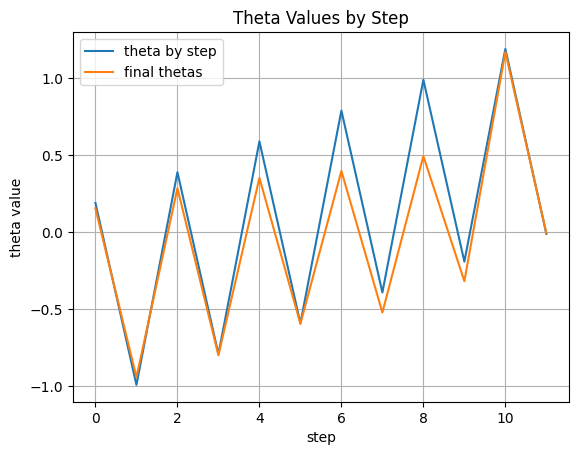

In [9]:
import matplotlib.pyplot as plt
theta_by_step =  [
          0.1900000001668666,
          -0.990000000152646,
          0.3900000000911187,
          -0.7900000001698143,
          0.5900000001648843,
          -0.5900000004982878,
          0.7900000002975271,
          -0.3900000004150855,
          0.9900000013105038,
          -0.19000000059643116,
          1.1900000164891396,
          -0.009999996127317518
        ]

final_thetas =[
          0.1546284079371182,
          -0.9400209414001843,
          0.2863153789396558,
          -0.7969594051296773,
          0.3531893736830792,
          -0.5929736813294777,
          0.3982704419546049,
          -0.52017039651539,
          0.4946730026926145,
          -0.3169211401102313,
          1.169443908893055,
          -0.005381952022066688
        ]

plt.plot(theta_by_step, label="theta by step")
plt.plot(final_thetas, label="final thetas")
plt.xlabel("step")
plt.ylabel("theta value")
plt.title("Theta Values by Step")
plt.legend()
plt.grid()

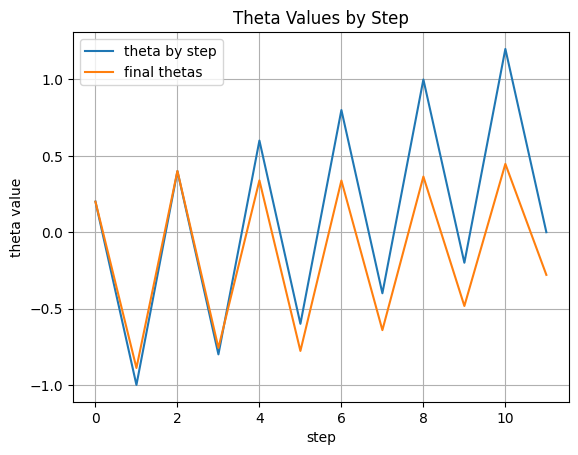

In [10]:
import matplotlib.pyplot as plt
theta_by_step =  [
        0.19999999999999998,
        -1.0,
        0.39999999999999997,
        -0.8,
        0.6,
        -0.6,
        0.7999999999999999,
        -0.4,
        1.0,
        -0.19999999999999996,
        1.2,
        -0.0
      ]

final_thetas = [
        0.1999178155016022,
        -0.8890828017493239,
        0.40087907262085315,
        -0.7575688401709084,
        0.33921390296636045,
        -0.7774606277157062,
        0.3381698577762516,
        -0.6412846670893788,
        0.3642072495418365,
        -0.48317012418271954,
        0.4472094822739201,
        -0.2794772658637772
      ]

plt.plot(theta_by_step, label="theta by step")
plt.plot(final_thetas, label="final thetas")
plt.xlabel("step")
plt.ylabel("theta value")
plt.title("Theta Values by Step")
plt.legend()
plt.grid()

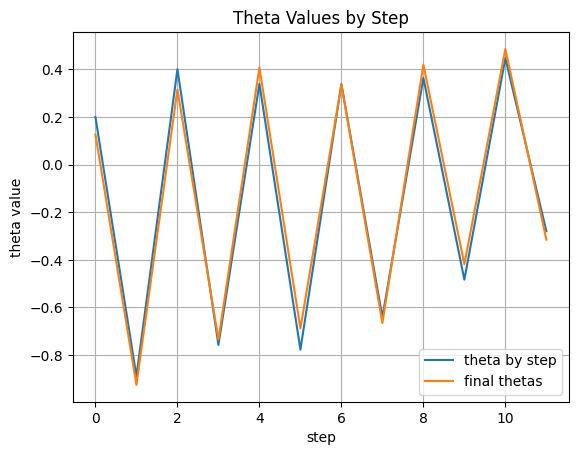

In [11]:
import matplotlib.pyplot as plt
theta_by_step = [
        0.1999178155016022,
        -0.8890828017493239,
        0.40087907262085315,
        -0.7575688401709084,
        0.33921390296636045,
        -0.7774606277157062,
        0.3381698577762516,
        -0.6412846670893788,
        0.3642072495418365,
        -0.48317012418271954,
        0.4472094822739201,
        -0.2794772658637772
      ]

final_thetas = [
          0.126070851998033,
          -0.92555275729213,
          0.3157123066929771,
          -0.734302690250151,
          0.40791307908083907,
          -0.6882067103499485,
          0.3360443542498708,
          -0.6655660341896465,
          0.4200818762501551,
          -0.4187228258686683,
          0.48600082139171763,
          -0.3152478625845897
        ]

plt.plot(theta_by_step, label="theta by step")
plt.plot(final_thetas, label="final thetas")
plt.xlabel("step")
plt.ylabel("theta value")
plt.title("Theta Values by Step")
plt.legend()
plt.grid()